In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
from functools import partial
import time
sys.path.append("..")
from src.models import NeuralPosteriorEstimator, MarginalDensityFlow
from src.data.reinfection import BaseReinfectionModel
from src.models.embedding import TransformerEmbedding
from src.criticism import c2st
mps_device = torch.device("mps")

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a

In [3]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)

In [11]:
base_dataset = BaseReinfectionModel(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, notebook=True,
                                   mode="criticism", load_data=False)
start = time.time()
base_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
base_dataset.resample(5)

Simulating samples...
Time to simulate 2,000 samples: 29.5s.


In [12]:
train_data, val_data = random_split(base_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

In [14]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(12, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 32.8 K | train
--------------------------------------
32.8 K    Trainable params
0         Non-trainable params
32.8 K    Total params
0.131     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

In [15]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                       | 0/? [00:00<?, ?it/s]

tensor(0.6088, dtype=torch.float64)

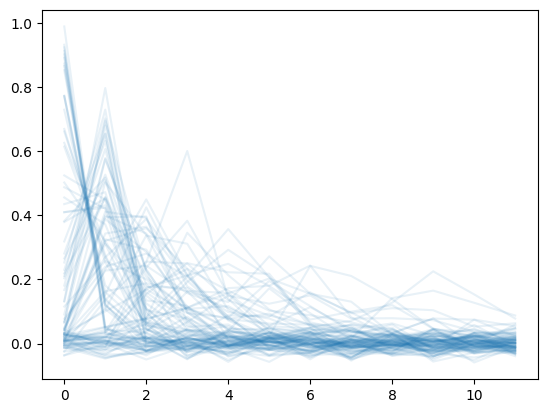

In [16]:
data_sample = base_dataset.data[:100].squeeze(1).T
plt.plot(data_sample, alpha=0.1, color="tab:blue")
plt.show()

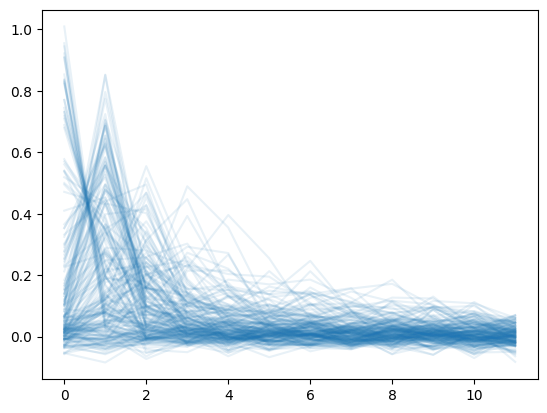

In [17]:
simulated_sample = samples[:200].T
plt.plot(simulated_sample, alpha=0.1, color="tab:blue")
plt.show()

In [ ]:
# x_sample = ch_dataset.data[:200].squeeze(1).T
# plt.plot(x_sample, alpha=0.1, color="tab:blue")
# plt.ylim(-0.1, 1.1)
# plt.show()

#### Third Pass: Learned Embeddings

The idea here is to apply an embedding network to the simulated data before running NPE. If we train NPE and the embedding network jointly, then the hope is that this embedding network learns an informative low-dimensional representation (e.g. summary statistic) of the data. My issue with this: it'd be different summary statistics for each model.